# 💎 Diamond Price Analysis
## Data Mining Final Project | CRISP-DM Methodology
---
**Dataset:** Diamonds Dataset (Kaggle) | 53,940 records  
**Team:** Mustafa Elsherif  and rawda attia  
**Goal:** Analyze diamond pricing using clustering, regression, anomaly detection & classification

In [9]:
# ============================================================
# IMPORTS
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning - Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Machine Learning - Classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Machine Learning - Anomaly Detection
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM

# Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_squared_error, r2_score,
                             classification_report, confusion_matrix)

# Warnings
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

 All libraries imported successfully!


---
## 1. Business Understanding

**Problem:** Diamond prices vary widely — what drives the price of a diamond?

**Business Questions:**
- Can we predict a diamond's price based on its features?
- Are there natural groups/segments of diamonds?
- Which diamonds are unusually priced (anomalies)?
- Can we classify diamond cut quality automatically?

**Success Criteria:**
- Regression R² > 0.90
- Clear and meaningful customer segments
- Detect outliers with explainable reasons
- Classification accuracy > 85%

---
## 2. Data Understanding

In [10]:
# ============================================================
# LOAD DATA
# ============================================================

import os
DATA_PATH = 'C:/Users/musta/dm-diamonds-analysis/data/'

df = pd.read_csv(DATA_PATH + 'diamonds.csv')

# Drop useless column
df = df.drop(columns=['Unnamed: 0'])

print(f"✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n--- First 5 rows ---")
df.head()

✅ Dataset loaded successfully!
📊 Shape: 53940 rows × 10 columns

--- First 5 rows ---


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [11]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("--- Dataset Info ---")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\n--- Column Types ---")
print(df.dtypes)
print(f"\n--- Missing Values ---")
print(df.isnull().sum())
print(f"\n--- Basic Statistics ---")
df.describe()

--- Dataset Info ---
Rows: 53940
Columns: 10

--- Column Types ---
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

--- Missing Values ---
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

--- Basic Statistics ---


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Dataset Overview Summary

**Size:** 53,940 diamonds × 10 features (after removing Unnamed: 0)

**Numerical Features (7):**
- carat — diamond weight (0.2 to 5.01)
- depth — total depth percentage (43 to 79)
- table — width of top of diamond (43 to 95)
- price — price in USD (326 to 18,823) ← target variable
- x, y, z — length, width, depth in mm

**Categorical Features (3):**
- cut — quality of the cut (Fair, Good, Very Good, Premium, Ideal)
- color — diamond color (D=best to J=worst)
- clarity — diamond clarity (IF=best to I1=worst)

**Data Quality (initial check):**
- No missing values in any column
- Zero values found in x, y, z → impossible for real diamonds
- Extreme outliers found in y and z → will be handled in Data Preparation
- Price is right-skewed → log transformation will be applied in modeling

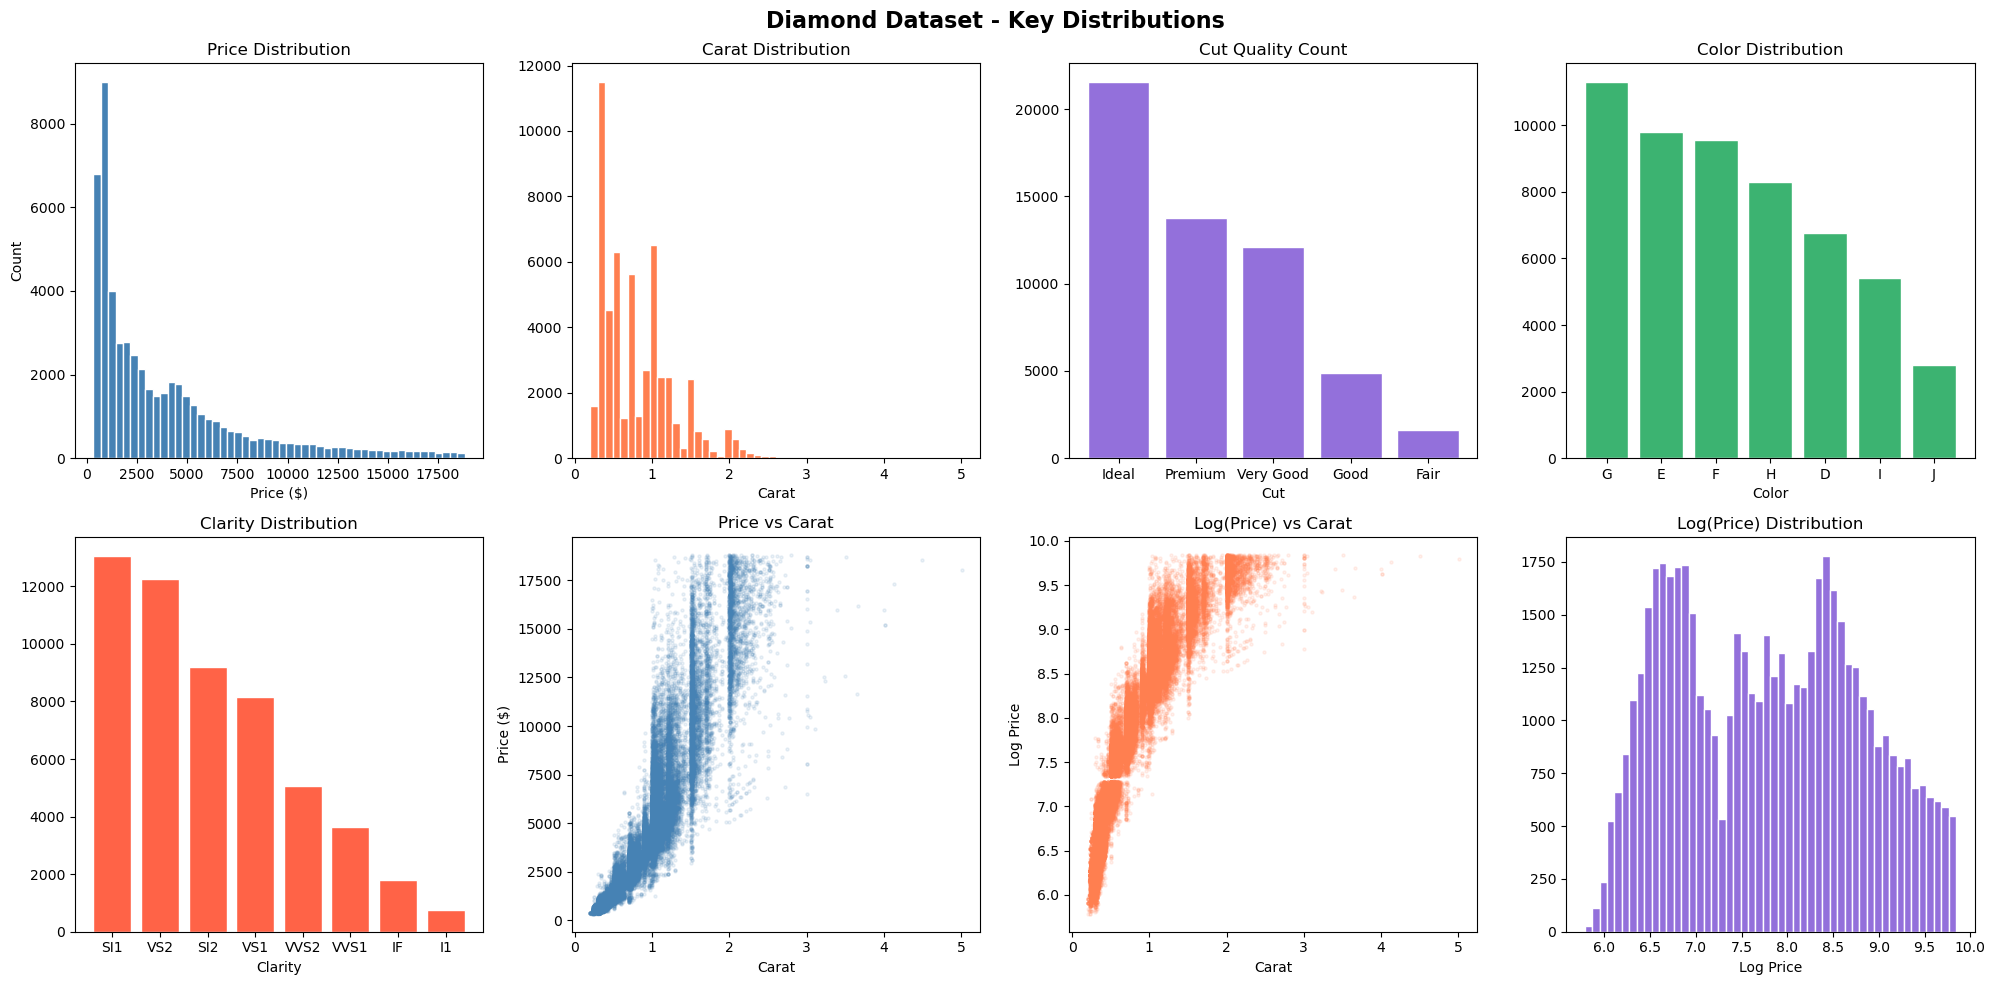

✅ Plots saved!


In [21]:
# ============================================================
# DATA VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Diamond Dataset - Key Distributions', fontsize=16, fontweight='bold')

# 1. Price distribution
axes[0,0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_ylabel('Count')

# 2. Carat distribution
axes[0,1].hist(df['carat'], bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Carat Distribution')
axes[0,1].set_xlabel('Carat')

# 3. Cut counts
cut_counts = df['cut'].value_counts()
axes[0,2].bar(cut_counts.index, cut_counts.values, color='mediumpurple', edgecolor='white')
axes[0,2].set_title('Cut Quality Count')
axes[0,2].set_xlabel('Cut')

# 4. Color counts
color_counts = df['color'].value_counts()
axes[0,3].bar(color_counts.index, color_counts.values, color='mediumseagreen', edgecolor='white')
axes[0,3].set_title('Color Distribution')
axes[0,3].set_xlabel('Color')

# 5. Clarity counts
clarity_counts = df['clarity'].value_counts()
axes[1,0].bar(clarity_counts.index, clarity_counts.values, color='tomato', edgecolor='white')
axes[1,0].set_title('Clarity Distribution')
axes[1,0].set_xlabel('Clarity')

# 6. Price vs Carat
axes[1,1].scatter(df['carat'], df['price'], alpha=0.1, color='steelblue', s=5)
axes[1,1].set_title('Price vs Carat')
axes[1,1].set_xlabel('Carat')
axes[1,1].set_ylabel('Price ($)')

# 7. Log Price vs Carat - shows true relationship
axes[1,2].scatter(df['carat'], np.log(df['price']), alpha=0.1, color='coral', s=5)
axes[1,2].set_title('Log(Price) vs Carat')
axes[1,2].set_xlabel('Carat')
axes[1,2].set_ylabel('Log Price')

# 8. Price distribution - log scale
axes[1,3].hist(np.log(df['price']), bins=50, color='mediumpurple', edgecolor='white')
axes[1,3].set_title('Log(Price) Distribution')
axes[1,3].set_xlabel('Log Price')

plt.tight_layout()
plt.savefig(DATA_PATH + 'eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plots saved!")

### Key Observations from Distributions

**Price & Carat:**
- Price is heavily right-skewed — most diamonds are under $2,500, few are very expensive
- Carat is also right-skewed — most diamonds are under 1 carat
- Price vs Carat shows a non-linear relationship with visible clusters at 0.5, 1.0, 1.5, 2.0 carat (people prefer round numbers)
- Log(Price) vs Carat becomes much cleaner and more linear → we will use log transformation in regression

**Cut, Color, Clarity:**
- Ideal cut is the most common (~40% of diamonds)
- Color G is the most common, J is the rarest
- SI1 and VS2 are the most common clarity grades
- IF (best clarity) is the rarest

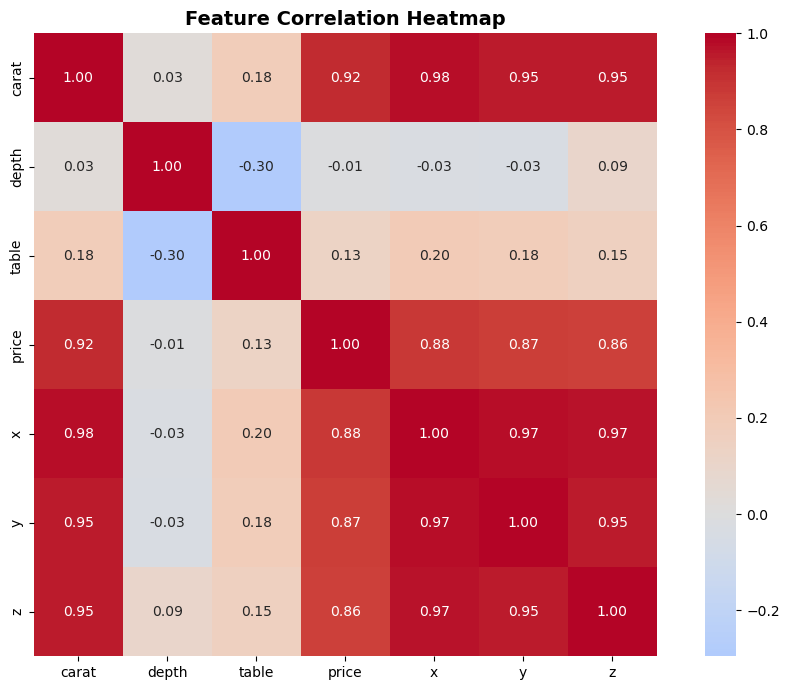

 Correlation heatmap saved!


In [16]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=np.number)
correlation = numeric_cols.corr()

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH + 'correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Correlation heatmap saved!")

### Key Observations from Correlation Heatmap

**Strong positive correlation with price:**
- carat → price = 0.92 (strongest feature)
- x → price = 0.88
- y → price = 0.87
- z → price = 0.86
- Note: x, y, z are highly correlated with carat (they represent physical size)

**Weak correlation with price:**
- depth → price = -0.01 (almost no effect)
- table → price = 0.13 (very weak)

**Key insight:**
Carat is the dominant predictor of price.
depth and table will likely have low importance in our models.
x, y, z may cause multicollinearity with carat — we will handle this in Data Preparation.

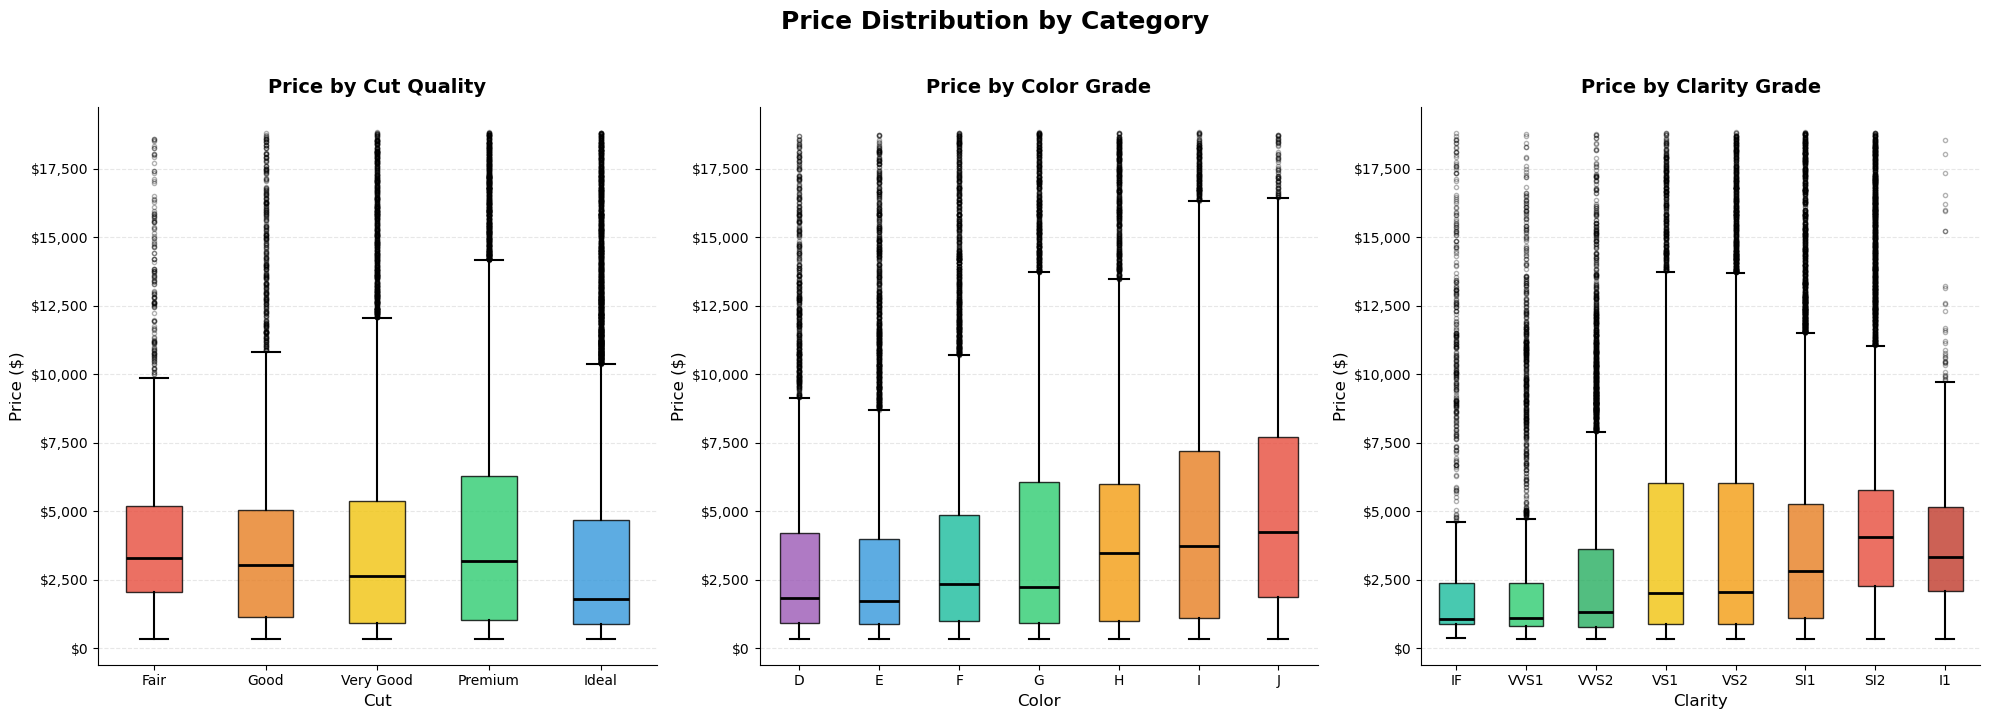

✅ Box plots saved!


In [23]:
# ============================================================
# BOX PLOTS - Price Distribution by Category
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Price Distribution by Category', fontsize=18, fontweight='bold', y=1.02)

cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_order = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

colors_cut     = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db']
colors_color   = ['#9b59b6','#3498db','#1abc9c','#2ecc71','#f39c12','#e67e22','#e74c3c']
colors_clarity = ['#1abc9c','#2ecc71','#27ae60','#f1c40f','#f39c12','#e67e22','#e74c3c','#c0392b']

# --- Plot function ---
def styled_boxplot(ax, data_list, labels, colors, title, xlabel):
    bp = ax.boxplot(data_list, labels=labels, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Price ($)', fontsize=12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 1. Price by Cut
styled_boxplot(axes[0],
               [df[df['cut']==c]['price'].values for c in cut_order],
               cut_order, colors_cut,
               'Price by Cut Quality', 'Cut')

# 2. Price by Color
styled_boxplot(axes[1],
               [df[df['color']==c]['price'].values for c in color_order],
               color_order, colors_color,
               'Price by Color Grade', 'Color')

# 3. Price by Clarity
styled_boxplot(axes[2],
               [df[df['clarity']==c]['price'].values for c in clarity_order],
               clarity_order, colors_clarity,
               'Price by Clarity Grade', 'Clarity')

plt.tight_layout()
plt.savefig(DATA_PATH + 'boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Box plots saved!")

### Key Observations from Box Plots

**Price by Cut — Surprising finding:**
- Ideal cut (best quality) has LOWER median price than Premium
- Reason: Ideal cut diamonds tend to come in smaller carats
- This confirms that carat dominates price more than cut quality

**Price by Color — Surprising finding:**
- D (best color) has LOWER median price than J (worst color)
- Same reason: lower color grade diamonds tend to be larger in carat
- This is called the "carat size confounding effect"

**Price by Clarity — Same pattern:**
- IF (best clarity) has the LOWEST median price
- SI2 has higher median price due to larger carat sizes

**Outliers:**
- All categories show many outliers above the upper whisker
- These are very large/expensive diamonds and are expected in the data
- They will be kept as they represent real high-value diamonds

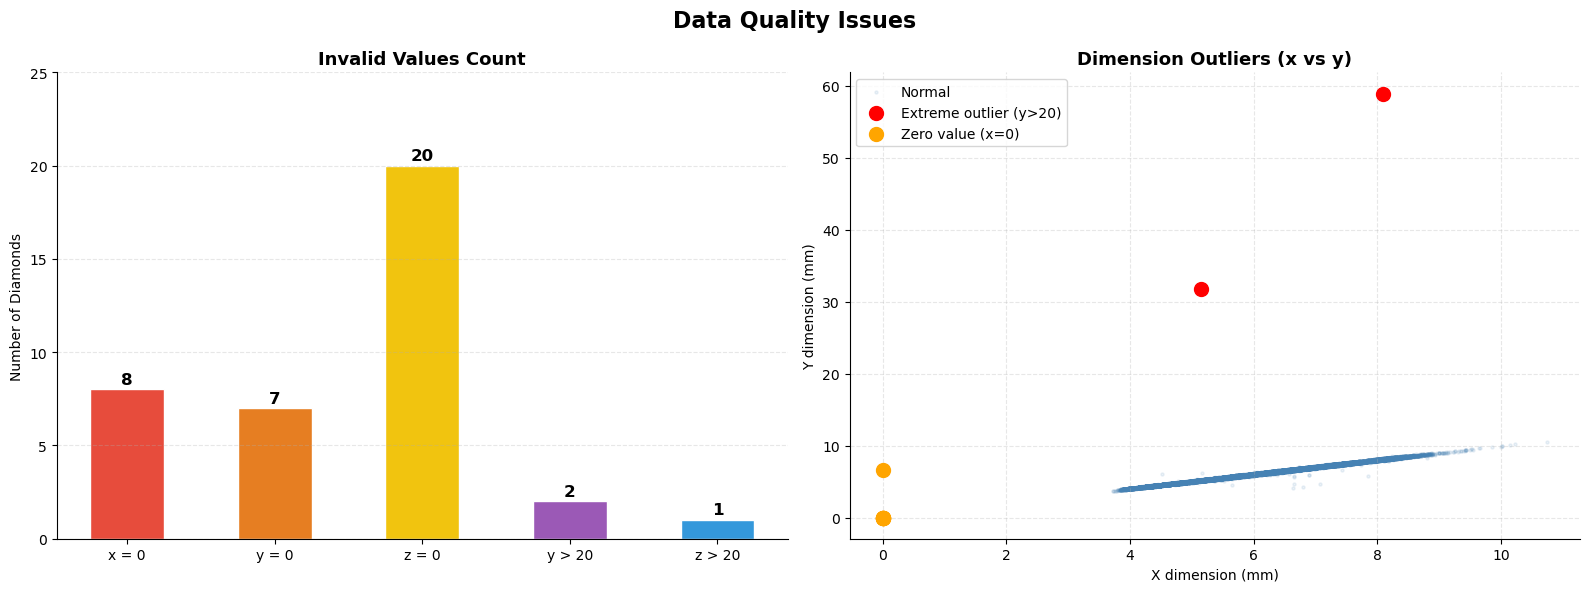

DATA QUALITY ISSUES SUMMARY
  x = 0 (impossible dimension): 8 diamonds
  y = 0 (impossible dimension): 7 diamonds
  z = 0 (impossible dimension): 20 diamonds
  y > 20mm (extreme outlier):   2 diamonds
  z > 20mm (extreme outlier):   1 diamonds
→ These will be removed in Data Preparation


In [24]:
# ============================================================
# ZERO VALUES & OUTLIERS DETECTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Data Quality Issues', fontsize=16, fontweight='bold')

# --- Left: Zero values bar chart ---
zero_counts = {
    'x = 0': df[df['x'] == 0].shape[0],
    'y = 0': df[df['y'] == 0].shape[0],
    'z = 0': df[df['z'] == 0].shape[0],
    'y > 20': df[df['y'] > 20].shape[0],
    'z > 20': df[df['z'] > 20].shape[0]
}

bars = axes[0].bar(zero_counts.keys(), zero_counts.values(),
                   color=['#e74c3c','#e67e22','#f1c40f','#9b59b6','#3498db'],
                   edgecolor='white', width=0.5)

for bar, val in zip(bars, zero_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=12, fontweight='bold')

axes[0].set_title('Invalid Values Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Diamonds')
axes[0].set_ylim(0, max(zero_counts.values()) + 5)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Right: Scatter showing extreme outliers ---
axes[1].scatter(df['x'], df['y'], alpha=0.1, s=5, color='steelblue', label='Normal')
axes[1].scatter(df[df['y'] > 20]['x'], df[df['y'] > 20]['y'],
                color='red', s=100, zorder=5, label='Extreme outlier (y>20)')
axes[1].scatter(df[df['x'] == 0]['x'], df[df['x'] == 0]['y'],
                color='orange', s=100, zorder=5, label='Zero value (x=0)')
axes[1].set_title('Dimension Outliers (x vs y)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('X dimension (mm)')
axes[1].set_ylabel('Y dimension (mm)')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_PATH + 'data_quality.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
print("=" * 45)
print("DATA QUALITY ISSUES SUMMARY")
print("=" * 45)
print(f"  x = 0 (impossible dimension): {df[df['x']==0].shape[0]} diamonds")
print(f"  y = 0 (impossible dimension): {df[df['y']==0].shape[0]} diamonds")
print(f"  z = 0 (impossible dimension): {df[df['z']==0].shape[0]} diamonds")
print(f"  y > 20mm (extreme outlier):   {df[df['y']>20].shape[0]} diamonds")
print(f"  z > 20mm (extreme outlier):   {df[df['z']>20].shape[0]} diamonds")
print("=" * 45)
print("→ These will be removed in Data Preparation")

### Key Observations from Data Quality Analysis

**Zero Values (impossible dimensions):**
- 8 diamonds have x = 0
- 7 diamonds have y = 0
- 20 diamonds have z = 0
- A real diamond cannot have zero dimensions - these are data entry errors

**Extreme Outliers:**
- 2 diamonds have y > 20mm (one has y = 58.9mm - impossible for a diamond)
- 1 diamond has z > 20mm (z = 31.8mm - impossible for a diamond)
- Normal diamond dimensions are between 3mm and 11mm

**Action Plan:**
- All zero-dimension diamonds will be removed in Data Preparation
- All extreme outliers (y > 20, z > 20) will be removed in Data Preparation
- Total rows to remove: ~35 out of 53,940 (less than 0.1% of data)
- This will not affect our analysis significantly

---
## 3. Technique Selection Rationale

### Why these techniques for diamonds?

| Technique | Algorithm | Reason |
|-----------|-----------|--------|
| Clustering | K-Means | Group diamonds into natural price/quality segments |
| Regression | Polynomial + Ridge | Price has non-linear relationship with carat (confirmed in EDA) |
| Anomaly Detection | One-Class SVM (+ PCA preprocessing) | Detect mispriced diamonds and invalid dimensions found in EDA |
| Classification | Random Forest | Classify cut quality, handles 5 classes and gives feature importance |

### Why not other techniques?
- Linear Regression alone - too simple, relationship is non-linear
- DBSCAN - varying density in diamonds data, K-Means gives cleaner segments
- Logistic Regression - 5 cut classes with complex boundaries, Random Forest handles better
- Simple SVM - One-Class SVM is specifically designed for anomaly detection
- PCA alone - only reduces dimensions, does not detect anomalies by itself

---
## CRISP-DM Plan

| Phase | Activities | Techniques |
|-------|-----------|------------|
| Business Understanding | Define problem & goals | — |
| Data Understanding | EDA, distributions, correlations | Pandas, Seaborn |
| Data Preparation | Clean, encode, scale | LabelEncoder, StandardScaler |
| Modelling | Apply 4 mining techniques | KMeans, LinearRegression, PCA, RandomForest |
| Evaluation | Metrics per technique | R², Silhouette, Accuracy |
| Deployment | Interactive dashboard | Streamlit |